# Quantization for Small Language Models

Quantization shrinks neural network weights and activations so that we can run models on smaller devices.
In this notebook we explore what quantization does, how it trades accuracy for speed and memory, and how to reason about the trade-offs when deploying a small language model (LM).

**Learning goals**
- See how floating point numbers are mapped into lower precision buckets.
- Measure the memory savings and accuracy impact of different bit-widths.
- Practice explaining the trade-offs to your classmates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 1. From Float32 to Int8
We start with a vector of values representing model weights. Quantization maps those 32-bit floating point values to 8-bit integers, together with a *scale* factor that lets us recover approximate float values later.

In [2]:
def quantize_per_tensor(x: np.ndarray, num_bits: int = 8):
    '''Return quantized values and scale for symmetric quantization.'''
    max_int = 2 ** (num_bits - 1) - 1
    max_val = np.max(np.abs(x))
    scale = max_val / max_int if max_val != 0 else 1.0
    q = np.clip(np.round(x / scale), -max_int - 1, max_int).astype(np.int8)
    return q, scale


def dequantize(q: np.ndarray, scale: float) -> np.ndarray:
    '''Reconstruct float values from quantized integers.'''
    return q.astype(np.float32) * scale


rng = np.random.default_rng(seed=4)
float_weights = rng.normal(loc=0.0, scale=0.8, size=1_000).astype(np.float32)

q8, scale8 = quantize_per_tensor(float_weights, num_bits=8)
float_reconstructed = dequantize(q8, scale8)

print('Scale factor:', round(scale8, 5))
print('Original dtype:', float_weights.dtype, '  Quantized dtype:', q8.dtype)
print('Mean absolute error:', np.mean(np.abs(float_weights - float_reconstructed)))
print('Max absolute error:', np.max(np.abs(float_weights - float_reconstructed)))


Scale factor: 0.02058
Original dtype: float32   Quantized dtype: int8
Mean absolute error: 0.0051890863
Max absolute error: 0.010284424


### Visualizing the effect
If plotting is available, compare the original and quantized values side-by-side.

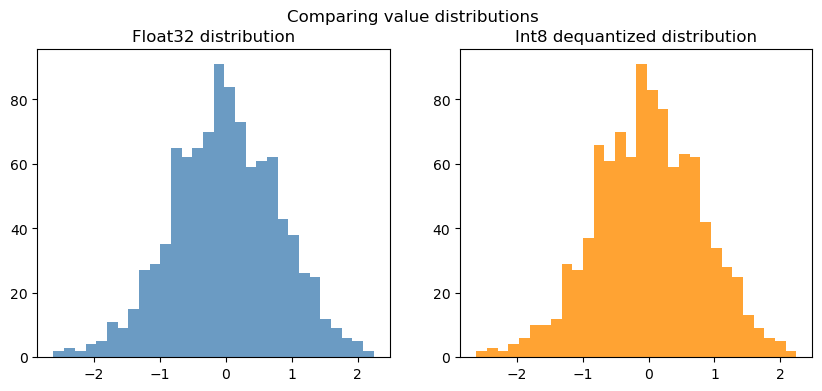

In [3]:
if 'plt' in globals():
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].hist(float_weights, bins=30, color='steelblue', alpha=0.8)
    ax[0].set_title('Float32 distribution')
    ax[1].hist(float_reconstructed, bins=30, color='darkorange', alpha=0.8)
    ax[1].set_title('Int8 dequantized distribution')
    fig.suptitle('Comparing value distributions')
    plt.show()
else:
    print('Plot skipped — enable matplotlib to visualize distributions.')


## 2. How much memory do we save?
Weights stored in 32-bit floats use 4 bytes per number, while int8 uses 1 byte. The scale value adds a tiny overhead per tensor.

In [4]:
float32_bytes = float_weights.nbytes
int8_bytes = q8.nbytes + scale8.nbytes  # scale is a float64 by default

print(f'Float32 storage: {float32_bytes / 1024:.2f} KB')
print(f'Int8 storage: {int8_bytes / 1024:.2f} KB')
print(f'Memory reduction: {(1 - int8_bytes / float32_bytes) * 100:.1f}%')


Float32 storage: 3.91 KB
Int8 storage: 0.98 KB
Memory reduction: 74.9%


## 3. Accuracy trade-offs across bit-widths
Lower bit-widths save even more memory but inject more error. Compare `float16`, `int8`, and `int4` style quantization.

In [5]:
def simulate_quant_error(x: np.ndarray, num_bits: int):
    q, scale = quantize_per_tensor(x, num_bits=num_bits)
    recon = dequantize(q, scale)
    mean_err = np.mean(np.abs(x - recon))
    max_err = np.max(np.abs(x - recon))
    storage = q.nbytes + scale.nbytes
    return mean_err, max_err, storage


bit_widths = [16, 8, 4]
results = []
for bits in bit_widths:
    if bits == 16:
        as_float16 = float_weights.astype(np.float16)
        recon = as_float16.astype(np.float32)
        mean_err = np.mean(np.abs(float_weights - recon))
        max_err = np.max(np.abs(float_weights - recon))
        storage = as_float16.nbytes
    else:
        mean_err, max_err, storage = simulate_quant_error(float_weights, num_bits=bits)
    results.append((bits, mean_err, max_err, storage))

for bits, mean_err, max_err, storage in results:
    print(f'{bits}-bit -> mean error {mean_err:.4f}, max error {max_err:.4f}, storage {storage/1024:.2f} KB')


16-bit -> mean error 0.0001, max error 0.0009, storage 1.95 KB
8-bit -> mean error 0.0052, max error 0.0103, storage 0.98 KB
4-bit -> mean error 0.0936, max error 0.1864, storage 0.98 KB


## 4. Quantization-aware linear layer
Quantization is often applied to matrix multiplications in transformer models. Below we quantize the weights of a linear layer and compare outputs.

In [6]:
def linear_forward(x: np.ndarray, weight: np.ndarray, bias: np.ndarray | None = None) -> np.ndarray:
    out = x @ weight.T
    if bias is not None:
        out = out + bias
    return out


weight = rng.normal(size=(4, 8)).astype(np.float32)
bias = rng.normal(size=(4,)).astype(np.float32)
activations = rng.normal(size=(3, 8)).astype(np.float32)

out_fp32 = linear_forward(activations, weight, bias)

q_weight, w_scale = quantize_per_tensor(weight.reshape(-1), num_bits=8)
q_weight = q_weight.reshape(weight.shape)
reconstructed_weight = dequantize(q_weight, w_scale).reshape(weight.shape)

out_int8 = linear_forward(activations, reconstructed_weight, bias)

mean_diff = np.mean(np.abs(out_fp32 - out_int8))
max_diff = np.max(np.abs(out_fp32 - out_int8))

print('Linear layer mean absolute difference:', mean_diff)
print('Linear layer max absolute difference:', max_diff)


Linear layer mean absolute difference: 0.014514327
Linear layer max absolute difference: 0.03560257


## 5. Cheat sheet
| Term | Meaning | Notes |
| --- | --- | --- |
| FP32 | 32-bit floating point | Training default; high accuracy, high memory. |
| FP16/BF16 | 16-bit float | Half the memory, limited dynamic range. |
| INT8 | 8-bit integer | Common for deployment; needs scales/zero-points. |
| INT4 | 4-bit integer | Aggressive compression; higher error. |
| GPTQ | Post-training quantization | Optimizes per-group scales to keep accuracy. |
| AWQ | Activation-aware weight quantization | Learns better scales using calibration data. |
| BitsAndBytes | Library for mixed-precision | Supports 8-bit + 4-bit inference on GPUs. |
| SmoothQuant | Moves activation range into weights | Reduces activation quant peaks. |


## 6. Explain it to a friend (Reflection)
- In your own words, why does quantization help you run models on laptops or phones?
- What is the main drawback of pushing bit-widths too low?
- How would you decide whether to use int8 or int4 for a new deployment?

## 7. Try it yourself (Exercises)
1. Swap the Gaussian weights for a real tensor from your project (copy in values) and re-run the notebook.
2. Implement per-channel quantization (one scale per output neuron) and compare the errors.
3. Measure the cosine similarity between `out_fp32` and `out_int8` to quantify how aligned the vectors remain.

In [7]:
# TODO: implement per-channel quantization here
# Hint: work row-by-row over the weight matrix, tracking a separate scale for each row.
